In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 1

%aimport search_model
%aimport simulation
import search_model as sm
import simulation as sim

/opt/homebrew/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:3649: RuntimeWarning: overflow encountered in exp
  return -x - np.exp(-x)


In [ ]:
J = 7
N = 10_000

product_id = np.arange(J + 1)

deltas_1 = np.ones(J + 1)
deltas_1[0] = 0.0

mus_1 = np.arange(J + 1).astype(float)
mus_1[0] = 0.0

a = 1.0
deltas_2 = deltas_1.copy()
mus_2 = mus_1.copy()

deltas_2[1:] = deltas_1[1:] + a
mus_2[1:] = mus_1[1:] + a

tab_ccp = pd.DataFrame({
    "delta_1": deltas_1,
    "mu_1": mus_1,
    "delta_2": deltas_2,
    "mu_2": mus_2,
    "delta_1 - mu_1": deltas_1 - mus_1,
    "delta_2 - mu_2": deltas_2 - mus_2,
    "Choice probabilities, set 1": sm.choice_probs_theory(deltas_1, mus_1),
    "Choice probabilities, set 2": sm.choice_probs_theory(deltas_2, mus_2),
})

tab_ccp.round(4)

,delta_1,mu_1,delta_2,mu_2,delta_1 - mu_1,delta_2 - mu_2,"Purchase probabilities, set 1","Purchase probabilities, set 2"
0,0.0,0.0,0.0,0.0,0.0,0.0,0.3875,0.3875
1,1.0,1.0,2.0,2.0,0.0,0.0,0.3875,0.3875
2,1.0,2.0,2.0,3.0,-1.0,-1.0,0.1426,0.1426
3,1.0,3.0,2.0,4.0,-2.0,-2.0,0.0524,0.0524
4,1.0,4.0,2.0,5.0,-3.0,-3.0,0.0193,0.0193
5,1.0,5.0,2.0,6.0,-4.0,-4.0,0.0071,0.0071
6,1.0,6.0,2.0,7.0,-5.0,-5.0,0.0026,0.0026
7,1.0,7.0,2.0,8.0,-6.0,-6.0,0.0010,0.0010


In [13]:
dat_1 = sim.simulate_single(N, J, deltas_1, mus_1, product_id, seed=123)
dat_2 = sim.simulate_single(N, J, deltas_2, mus_2, product_id, seed=123)

dat_1['searched'] = dat_1['r'] >= dat_1.groupby(level='i')['w'].transform('max')
dat_2['searched'] = dat_2['r'] >= dat_2.groupby(level='i')['w'].transform('max')

tab_search = pd.concat([
    dat_1.groupby('d')['searched'].mean().to_frame('Set 1'), 
    dat_2.groupby('d')['searched'].mean().to_frame('Set 2')
], axis=1)


tab_search["Difference"] = tab_search["Set 2"] - tab_search["Set 1"]
tab_search.round(4)

,Set 1,Set 2,Difference
d,,,
0,0.1758,0.1359,-0.0398
1,0.2670,0.2533,-0.0137
2,0.2885,0.2584,-0.0301
3,0.2986,0.2604,-0.0382
4,0.3044,0.2597,-0.0447
5,0.3049,0.2641,-0.0408
6,0.3036,0.2644,-0.0391
7,0.3250,0.2639,-0.0611


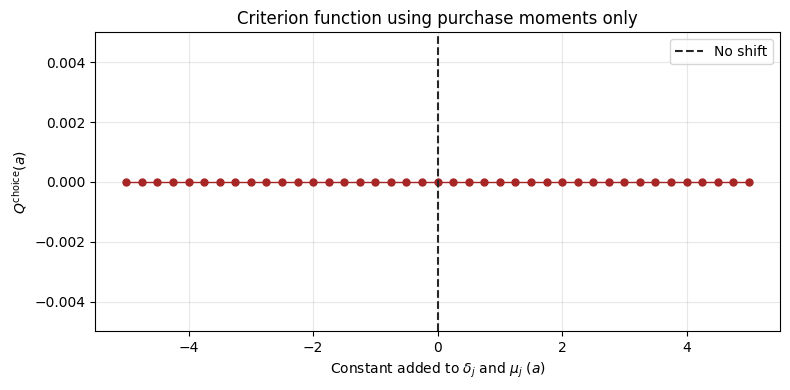

In [34]:
s_obs = sm.choice_probs_theory(deltas_1, mus_1)

def Q_choice(a):
    deltas_a = deltas_1.copy()
    mus_a = mus_1.copy()
    deltas_a[1:] = deltas_1[1:] + a
    mus_a[1:] = mus_1[1:] + a

    s_model = sm.choice_probs_theory(deltas_a, mus_a)
    return np.sum((s_obs - s_model) ** 2)

a_grid = np.linspace(-5, 5, 41)
Q_vals = np.array([Q_choice(a) for a in a_grid])


plt.figure(figsize=(8,4))
plt.plot(a_grid, Q_vals, marker='o', markersize=5, linewidth=1, color='#a62626')

plt.axvline(0, linestyle='--', linewidth=1.5, label=r"No shift", color="#262626")

plt.xlabel(r"Constant added to $\delta_j$ and $\mu_j$ ($a$)")
plt.ylabel(r"$Q^{\mathrm{choice}}(a)$")
plt.title("Criterion function using purchase moments only")
plt.ylim(-0.005, 0.005)
plt.legend()
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()